# Feature Engineering and Model Exploration

Explore feature distributions for match vs non-match pairs, train the LightGBM model, and inspect what it learned.

In [9]:
import os

PROJECT_ROOT = os.path.expanduser("~/Documents/entity-resolution-pipeline")
os.chdir(PROJECT_ROOT)

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from er.config import load_config
from er.features import FEATURE_NAMES, compute_features
from er.pipeline import load_data

config = load_config("configs/amazon_google.yaml")
df_a, df_b, train, valid, test = load_data(config)

# Load cached embeddings
embs_a = np.load("artifacts/embeddings_a.npz")
embs_b = np.load("artifacts/embeddings_b.npz")
embeddings_a = (embs_a["name"], embs_a["record"])
embeddings_b = (embs_b["name"], embs_b["record"])

# Compute features for training split
X_train = compute_features(train, df_a, df_b, embeddings_a, embeddings_b)
y_train = train["label"].values
print(f"Feature matrix: {X_train.shape} ({len(FEATURE_NAMES)} features)")

Feature matrix: (6874, 20) (20 features)


## Feature Distributions: Match vs Non-Match

The most useful features should show clear separation between match (1) and non-match (0) pairs.

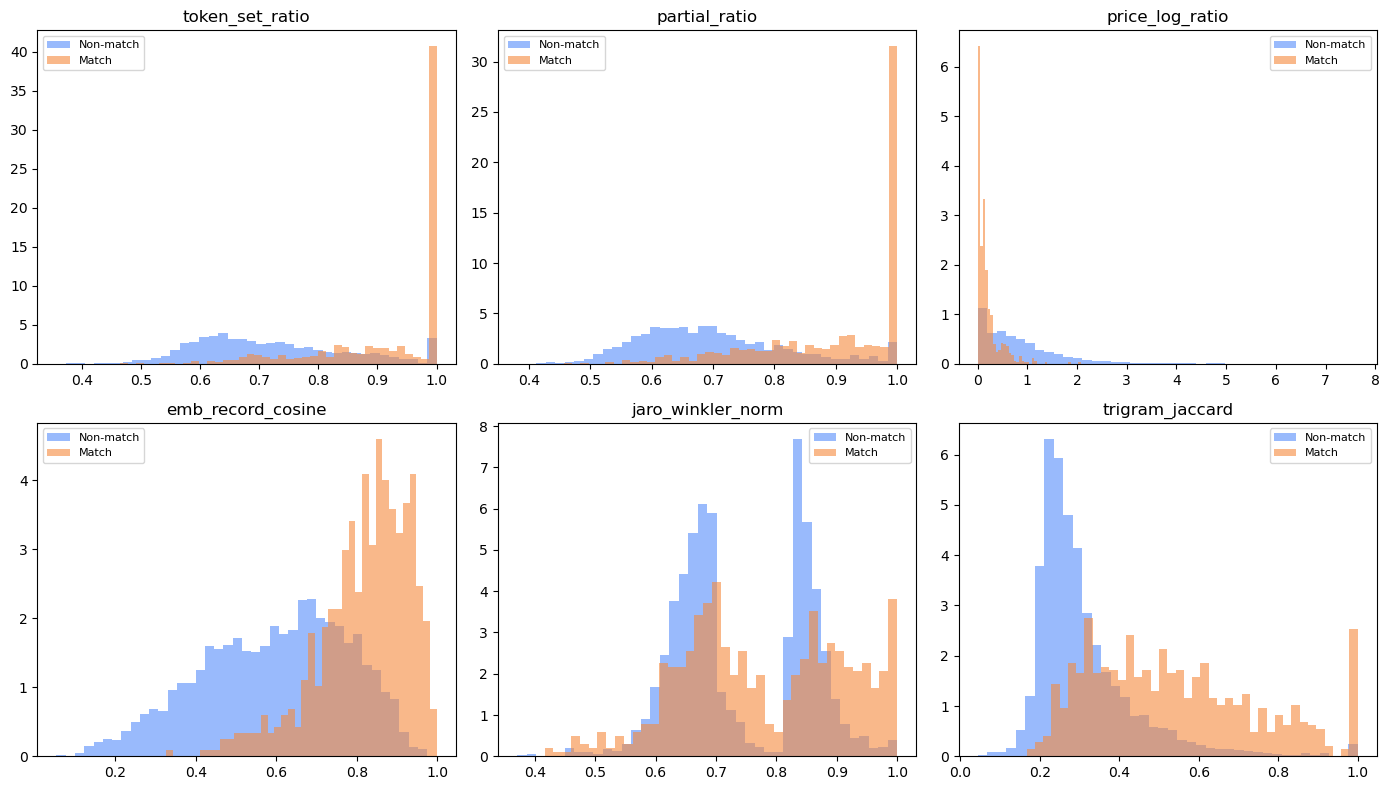

In [10]:
top_features = ["token_set_ratio", "partial_ratio", "price_log_ratio",
                "emb_record_cosine", "jaro_winkler_norm", "trigram_jaccard"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, fname in zip(axes.flat, top_features):
    idx = FEATURE_NAMES.index(fname)
    vals = X_train[:, idx]
    mask = ~np.isnan(vals)
    ax.hist(vals[mask & (y_train == 0)], bins=40, alpha=0.6, label="Non-match", density=True)
    ax.hist(vals[mask & (y_train == 1)], bins=40, alpha=0.6, label="Match", density=True)
    ax.set_title(fname)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Model Training and Feature Importance

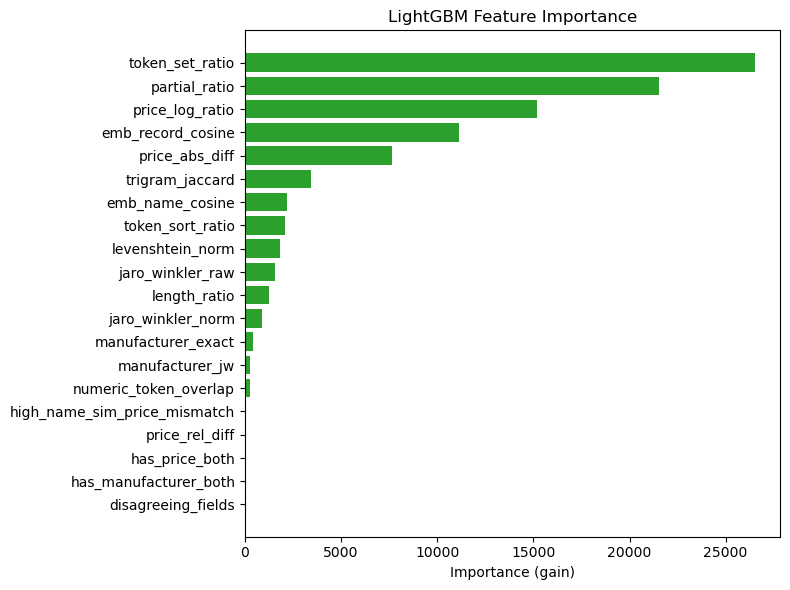


Top 10 features:
  token_set_ratio                     26,502
  partial_ratio                       21,539
  price_log_ratio                     15,213
  emb_record_cosine                   11,122
  price_abs_diff                      7,627
  trigram_jaccard                     3,433
  emb_name_cosine                     2,173
  token_sort_ratio                    2,086
  levenshtein_norm                    1,837
  jaro_winkler_raw                    1,540


In [11]:
import lightgbm as lgb

model = lgb.Booster(model_file="artifacts/model.txt")

importance = model.feature_importance(importance_type="gain")
sorted_idx = np.argsort(importance)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([FEATURE_NAMES[i] for i in sorted_idx], importance[sorted_idx], color="tab:green")
ax.set_xlabel("Importance (gain)")
ax.set_title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for i in sorted_idx[::-1][:10]:
    print(f"  {FEATURE_NAMES[i]:35s} {importance[i]:,.0f}")

## Error Analysis: False Positives and False Negatives

The spec says: "Print 10 false positives and 10 false negatives and read them. Single most useful move."

In [12]:
from er.calibrate import calibrate

X_valid = compute_features(valid, df_a, df_b, embeddings_a, embeddings_b)
y_valid = valid["label"].values
X_test = compute_features(test, df_a, df_b, embeddings_a, embeddings_b)
y_test = test["label"].values

cal_model, threshold = calibrate(model, X_valid, y_valid)
probs = cal_model.predict_proba(X_test)
preds = (probs >= threshold).astype(int)

# False positives: predicted match but actually non-match
fp_mask = (preds == 1) & (y_test == 0)
fp_indices = np.where(fp_mask)[0][:10]
print(f"=== FALSE POSITIVES ({fp_mask.sum()} total, showing 10) ===\n")
for i in fp_indices:
    row = test.iloc[i]
    ra = df_a.loc[row.ltable_id]
    rb = df_b.loc[row.rtable_id]
    print(f"  prob={probs[i]:.3f}")
    print(f"  A: {ra.title} | mfr={ra.get('manufacturer','?')} | price={ra.get('price','?')}")
    print(f"  B: {rb.title} | mfr={rb.get('manufacturer','?')} | price={rb.get('price','?')}")
    print()

# False negatives: predicted non-match but actually match
fn_mask = (preds == 0) & (y_test == 1)
fn_indices = np.where(fn_mask)[0][:10]
print(f"=== FALSE NEGATIVES ({fn_mask.sum()} total, showing 10) ===\n")
for i in fn_indices:
    row = test.iloc[i]
    ra = df_a.loc[row.ltable_id]
    rb = df_b.loc[row.rtable_id]
    print(f"  prob={probs[i]:.3f}")
    print(f"  A: {ra.title} | mfr={ra.get('manufacturer','?')} | price={ra.get('price','?')}")
    print(f"  B: {rb.title} | mfr={rb.get('manufacturer','?')} | price={rb.get('price','?')}")
    print()

=== FALSE POSITIVES (137 total, showing 10) ===

  prob=0.562
  A: adobe cs3 design standard macosx dvd | mfr=adobe | price=399.0
  B: adobe cs3 design standard upgrade | mfr=nan | price=413.99

  prob=0.362
  A: videostudio 11 plus | mfr=corel | price=nan
  B: video studio 11 plus | mfr=corel corporation | price=103.99

  prob=0.622
  A: westward | mfr=encore software | price=19.99
  B: encore software 13781 westward | mfr=nan | price=17.97

  prob=0.421
  A: rainbow fish and the whale ( win/mac ) | mfr=global-software-publishing | price=9.99
  B: rainbow fish and the whale | mfr=nan | price=6.95

  prob=0.362
  A: wheel of fortune deluxe | mfr=encore | price=19.99
  B: wheel of fortune ( r ) | mfr=nan | price=19.99

  prob=0.362
  A: microsoft word 2004 upgrade ( mac ) | mfr=microsoft | price=109.99
  B: word mac 2004 upgrade microsoft d48-00488 | mfr=nan | price=97.36

  prob=0.716
  A: professor teaches excel & word | mfr=individual software | price=19.99
  B: individual software p